In [ ]:
!pip install -U diffusers

## Local Inference on GPU
Model page: https://huggingface.co/Roman190928/12MLangModel15000

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/Roman190928/12MLangModel15000)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
pip install -U diffusers transformers accelerate datasets

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer
from datasets import load_dataset

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

### Identified the task to be performed

The task is **causal language modeling**, which means predicting the next word in a sequence. This is suitable for text generation.

### Identified the domain used for fine-tuning

For this demonstration, we will use a dataset of **English quotes** to fine-tune the model, making it more proficient at generating quote-like text.

### Identified the LLM to be used

We will use the **GPT-2** model from Hugging Face, specifically `gpt2`, as it's a widely used and capable causal language model suitable for fine-tuning on various text generation tasks.

### Load the Pre-trained Model and Tokenizer

In [6]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer # Added AutoModelForCausalLM, AutoTokenizer

# Set device (moved or redefined here to ensure 'device' is available)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

# GPT-2 does not have a default pad token, which is needed for batch processing
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = model.config.eos_token_id

print(f"Model and tokenizer loaded for {model_name} on device: {device}")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model and tokenizer loaded for gpt2 on device: cuda


### Prepare the Dataset for Fine-tuning

We'll use the `Abirate/english_quotes` dataset from Hugging Face. This dataset contains a collection of English quotes, which is perfect for our text generation task in the 'quotes' domain.

In [7]:
from datasets import load_dataset # Added load_dataset

dataset_name = "Abirate/english_quotes"
dataset = load_dataset(dataset_name)

# Only use the 'train' split for this example
data = dataset['train']

print(f"Dataset '{dataset_name}' loaded. Number of samples: {len(data)}")
print("First sample:", data[0])

def tokenize_function(examples):
    return tokenizer(examples["quote"], truncation=True, max_length=128)

tokenized_data = data.map(tokenize_function, batched=True, remove_columns=["quote", "author"])

# Group texts together to create larger blocks of text, suitable for causal language modeling
block_size = 128

def group_texts(examples):
    # Concatenate all texts.
    concatenated_examples = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated_examples[list(examples.keys())[0]])
    # We drop the small remainder, we could add padding if the model supported it instead of this drop, you can
    # customize this part to your needs.
    total_length = (total_length // block_size) * block_size
    # Split by chunks of max_len.
    result = {
        k: [t[i : i + block_size] for i in range(0, total_length, block_size)]
        for k, t in concatenated_examples.items()
    }
    result["labels"] = result["input_ids"].copy()
    return result

lm_dataset = tokenized_data.map(
    group_texts,
    batched=True,
    batch_size=1000,
    num_proc=4, # Use multiple processes for faster processing
)

print("\nTokenized and grouped dataset sample:", lm_dataset[0])
print(f"Number of samples after grouping: {len(lm_dataset)}")

README.md: 0.00B [00:00, ?B/s]

quotes.jsonl:   0%|          | 0.00/647k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2508 [00:00<?, ? examples/s]

Dataset 'Abirate/english_quotes' loaded. Number of samples: 2508
First sample: {'quote': '“Be yourself; everyone else is already taken.”', 'author': 'Oscar Wilde', 'tags': ['be-yourself', 'gilbert-perreira', 'honesty', 'inspirational', 'misattributed-oscar-wilde', 'quote-investigator']}


Map:   0%|          | 0/2508 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/2508 [00:00<?, ? examples/s]


Tokenized and grouped dataset sample: {'tags': ['be-yourself', 'gilbert-perreira', 'honesty', 'inspirational', 'misattributed-oscar-wilde', 'quote-investigator', 'best', 'life', 'love', 'mistakes', 'out-of-control', 'truth', 'worst', 'human-nature', 'humor', 'infinity', 'philosophy', 'science', 'stupidity', 'universe', 'books', 'humor', 'books', 'simile', 'soul', 'ataraxy', 'be-yourself', 'confidence', 'fitting-in', 'individuality', 'misattributed-dr-seuss', 'those-who-matter', 'dance', 'heaven', 'hurt', 'inspirational', 'life', 'love', 'sing', 'dreams', 'love', 'reality', 'sleep', 'humor', 'life', 'action', 'change', 'inspirational', 'philosophy', 'wish', 'life', 'character', 'sirius-black', 'friends', 'friendship', 'misattributed-albert-camus', 'lies', 'lying', 'memory', 'truth', 'friendship', 'friend', 'friendship', 'knowledge', 'love', 'enemies', 'forgiveness', 'strategy', 'life', 'carpe-diem', 'education', 'inspirational', 'learning', 'darkness', 'drive-out', 'hate', 'inspiration

### Established the configuration needed for fine-tuning

We will define the `TrainingArguments` which specify various parameters for the training process, such as output directory, learning rate, number of epochs, and logging settings. Then, we'll initialize the `Trainer`.

In [13]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling # Added DataCollatorForLanguageModeling

training_args = TrainingArguments(
    output_dir="./gpt2_finetuned_quotes",
    # overwrite_output_dir=True, # Removed this argument as it caused a TypeError
    num_train_epochs=3, # You can adjust this
    per_device_train_batch_size=8, # Adjust based on GPU memory
    save_steps=10_000,
    save_total_limit=2,
    logging_dir='./logs',
    logging_steps=500,
    learning_rate=5e-5,
    prediction_loss_only=True,
    report_to="none" # Disable report to wandb or other services if not configured
)

# Initialize DataCollator for Language Modeling
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False) # mlm=False for causal language modeling

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=lm_dataset,
    # tokenizer=tokenizer, # Removed tokenizer from here and passed data_collator instead
    data_collator=data_collator,
)

print("Training arguments and Trainer initialized.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments and Trainer initialized.


### Perform Fine-tuning

In [14]:
print("Starting fine-tuning...")
trainer.train()
print("Fine-tuning complete. Saving the fine-tuned model.")

# Save the fine-tuned model
trainer.save_model("gpt2_finetuned_quotes_model") # Changed path from './gpt2_finetuned_quotes_model'
tokenizer.save_pretrained("gpt2_finetuned_quotes_model") # Changed path from './gpt2_finetuned_quotes_model'
print("Model saved to 'gpt2_finetuned_quotes_model'")

Starting fine-tuning...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning complete. Saving the fine-tuned model.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to 'gpt2_finetuned_quotes_model'


### Performed Evaluation: Text Generation

After fine-tuning, let's test our model by generating some text to see how well it learned the style of quotes. We will load the fine-tuned model and tokenizer, and then use a simple prompt to generate a new quote.

In [15]:
import torch # Added torch
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM # Added AutoTokenizer, AutoModelForCausalLM

# Set device (redefined here to ensure 'device' is available)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the fine-tuned model and tokenizer
finetuned_model_path = "gpt2_finetuned_quotes_model" # Changed path from './gpt2_finetuned_quotes_model'
finetuned_tokenizer = AutoTokenizer.from_pretrained(finetuned_model_path)
finetuned_model = AutoModelForCausalLM.from_pretrained(finetuned_model_path).to(device)

gen = pipeline('text-generation', model=finetuned_model, tokenizer=finetuned_tokenizer, device=0 if torch.cuda.is_available() else -1)

# Generate text
prompt = "The only way to do great work is to "
print(f"\nGenerating text with prompt: '{prompt}'")

generated_texts = gen(prompt, max_length=50, num_return_sequences=1, do_sample=True, top_k=50, top_p=0.95, temperature=0.7)

for i, text in enumerate(generated_texts):
    print(f"Generated text {i+1}:\n{text['generated_text']}")

print("\nThis demonstrates the fine-tuned model's ability to generate text based on the training data. The quality of generated text can be further improved by adjusting training parameters, increasing epochs, or using a larger/more diverse dataset.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'max_length', 'top_p', 'do_sample', 'top_k', 'num_return_sequences', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Generating text with prompt: 'The only way to do great work is to '
Generated text 1:
The only way to do great work is to  be able to do it in a way that does not annoy me. That is not to say that we can't do good works but that we can't do great work in the way that is best for us. I will not say that my life is beautiful but that it is beautiful in spite of the things that I say. I am not a fairy tale, but I am a man who has got to live with the world in a state of perpetual darkness. I am a man who has to live with his own family in a state of constant pain. I am a man who has to live in a state of perpetual pain because I am a man who lives with the world in a state of constant pain.  I am not a fairy tale but I am a man who has got to live in a state of perpetual pain because I am a man who lives in a state of perpetual pain.  I am not a man who has got to live in a state of perpetual pain because I am a man who lives in a state of perpetual pain.  I am not a man who has got to l

### 1. Visualize Word Embeddings using PCA

To understand the relationships between words learned by the fine-tuned model, we can visualize their embeddings using Principal Component Analysis (PCA). PCA reduces the dimensionality of the embeddings to 2D, allowing us to plot them on a scatter graph.

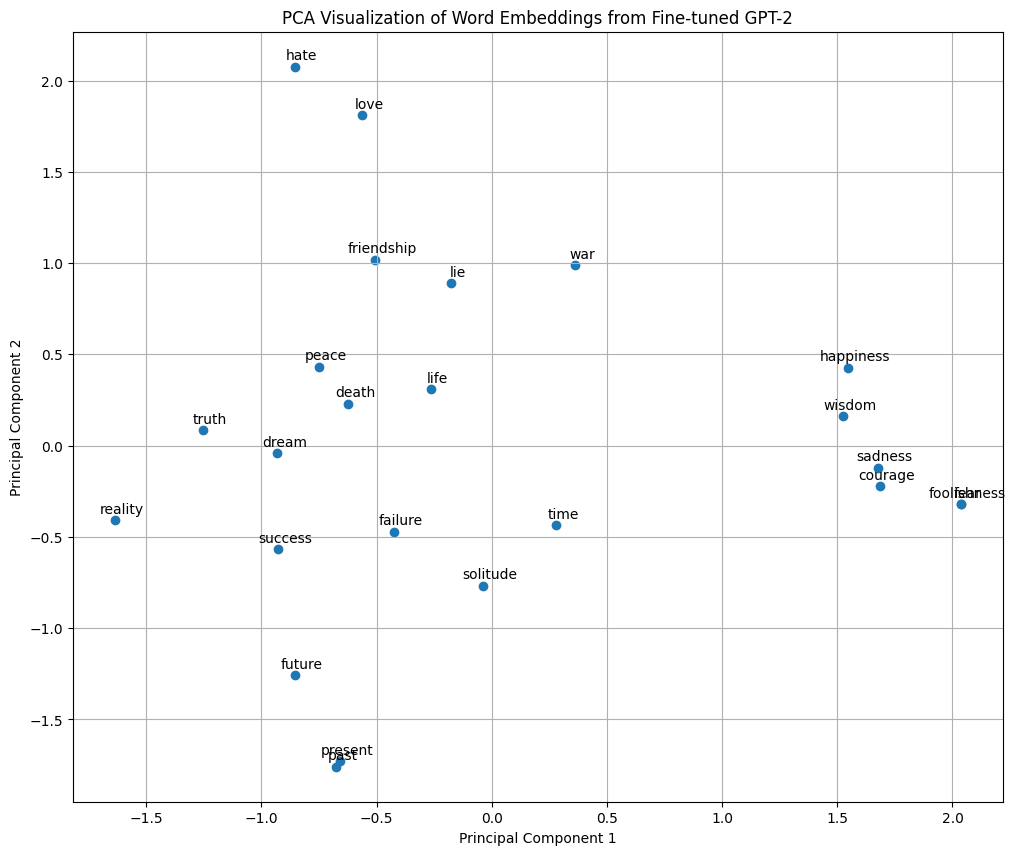

In [16]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Select at least 20 known words for visualization
# Choosing words that might be relevant to quotes or general language
words = [
    "love", "hate", "life", "death", "happiness", "sadness", "wisdom", "foolishness",
    "success", "failure", "dream", "reality", "courage", "fear", "peace", "war",
    "truth", "lie", "friendship", "solitude", "time", "future", "past", "present"
]

# Get token IDs for the words
# Ensure the words are correctly tokenized; some might split into multiple tokens
# For simplicity, we'll take the first token's embedding if a word splits
word_ids = [finetuned_tokenizer.encode(word)[0] for word in words]

# Extract embeddings for these token IDs
# The embeddings are typically stored in the model's 'transformer.wte.weight' (word token embeddings)
word_embeddings = finetuned_model.transformer.wte.weight[word_ids].detach().cpu().numpy()

# Perform PCA to reduce dimensionality to 2D
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(word_embeddings)

# Plot the reduced embeddings
plt.figure(figsize=(12, 10))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]), textcoords="offset points", xytext=(5,5), ha='center')

plt.title('PCA Visualization of Word Embeddings from Fine-tuned GPT-2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()